# Partie III – RNN, LSTM, GRU et Seq2Seq

Traduction automatique simplifiée **fra → eng** (Tatoeba).

- RNN / LSTM / GRU, gradient clipping
- Seq2Seq encodeur-décodeur, teacher forcing
- Décodage greedy et beam search, score BLEU

> Exécuter les cellules dans l'ordre. Les figures s'affichent sous chaque cellule et sont aussi enregistrées dans `figures/`.


In [1]:
#Idem, configure le répertoire racine.
%matplotlib inline
from pathlib import Path
import os

ROOT = Path.cwd()
if not (ROOT / "partie1_mlp").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)



## Configuration et imports


In [2]:
#Importe outils NLP (regex, zipfile, Counter, pad_sequence), fixe batch=128, epochs=8, embed=64, hidden=128, max 5000 paires de phrases
import copy
import json
import math
import re
import zipfile
from collections import Counter
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
DATA_DIR = ROOT / "data" / "fra-eng"
FIG_DIR = ROOT / "figures" / "partie3"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 128
EPOCHS = 8
CLIP_EPOCHS = 5
LR = 1e-3
EMBED_DIM = 64
HIDDEN_DIM = 128
MAX_PAIRS = 5000
MAX_LEN = 15
BEAM_WIDTH = 3


## 1. Téléchargement et préparation des données


In [3]:
#Télécharge (ou corpus de secours) les paires fra/eng, nettoie le texte, construit un Vocabulary (mot↔indice),
#un collate_batch pour le padding, et un Dataset qui encode les phrases avec <sos>/<eos>
FALLBACK_PAIRS = [
    ("bonjour", "hello"),
    ("au revoir", "goodbye"),
    ("merci", "thank you"),
    ("oui", "yes"),
    ("non", "no"),
    ("comment allez vous", "how are you"),
    ("je suis content", "i am happy"),
    ("elle est belle", "she is beautiful"),
    ("il est grand", "he is tall"),
    ("nous allons manger", "we are going to eat"),
    ("ils sont ici", "they are here"),
    ("j aime le chocolat", "i love chocolate"),
    ("tu es mon ami", "you are my friend"),
    ("le chat est noir", "the cat is black"),
    ("la maison est grande", "the house is big"),
    ("je vais a paris", "i am going to paris"),
    ("elle lit un livre", "she reads a book"),
    ("il travaille dur", "he works hard"),
    ("nous apprenons le francais", "we learn french"),
    ("ils jouent au foot", "they play soccer"),
    ("bonne nuit", "good night"),
    ("bon appetit", "enjoy your meal"),
    ("s il vous plait", "please"),
    ("je ne comprends pas", "i do not understand"),
    ("ou est la gare", "where is the station"),
    ("quelle heure est il", "what time is it"),
    ("j ai froid", "i am cold"),
    ("elle a chaud", "she is hot"),
    ("nous sommes fatigues", "we are tired"),
    ("ils sont en retard", "they are late"),
    ("le ciel est bleu", "the sky is blue"),
    ("la mer est calme", "the sea is calm"),
    ("je mange une pomme", "i eat an apple"),
    ("tu dors bien", "you sleep well"),
    ("il ecoute la musique", "he listens to music"),
    ("elle danse vite", "she dances fast"),
    ("nous voyageons souvent", "we travel often"),
    ("ils etudient ensemble", "they study together"),
    ("c est mon chien", "this is my dog"),
    ("voici ma mere", "here is my mother"),
    ("j adore cette ville", "i love this city"),
    ("le train arrive", "the train arrives"),
    ("la porte est ouverte", "the door is open"),
    ("je prends le bus", "i take the bus"),
    ("tu viens avec moi", "you come with me"),
    ("il parle anglais", "he speaks english"),
    ("elle ecrit une lettre", "she writes a letter"),
    ("nous regardons la tele", "we watch tv"),
    ("ils cuisinent le diner", "they cook dinner"),
    ("bonne chance", "good luck"),
    ("a bientot", "see you soon"),
    ("je suis perdu", "i am lost"),
    ("elle est docteur", "she is a doctor"),
    ("il est professeur", "he is a teacher"),
    ("nous avons deux enfants", "we have two children"),
    ("ils vivent en france", "they live in france"),
    ("le cafe est chaud", "the coffee is hot"),
    ("la pluie tombe", "the rain falls"),
    ("je cours chaque matin", "i run every morning"),
    ("tu nages bien", "you swim well"),
    ("il peint un tableau", "he paints a picture"),
    ("elle plante des fleurs", "she plants flowers"),
    ("nous chantons une chanson", "we sing a song"),
    ("ils nettoient la maison", "they clean the house"),
    ("c est tres important", "this is very important"),
    ("je veux de l eau", "i want some water"),
    ("tu es tres gentil", "you are very kind"),
    ("il fait beau aujourd hui", "it is nice today"),
    ("elle porte une robe rouge", "she wears a red dress"),
    ("nous partons demain", "we leave tomorrow"),
    ("ils arrivent ce soir", "they arrive tonight"),
    ("le livre est sur la table", "the book is on the table"),
    ("la voiture est rapide", "the car is fast"),
    ("je cherche mon telephone", "i look for my phone"),
    ("tu connais cette chanson", "you know this song"),
    ("il ouvre la fenetre", "he opens the window"),
    ("elle ferme la porte", "she closes the door"),
    ("nous achetons du pain", "we buy bread"),
    ("ils vendent des fruits", "they sell fruits"),
    ("je suis etudiant", "i am a student"),
    ("tu es medecin", "you are a doctor"),
    ("il est avocat", "he is a lawyer"),
    ("elle est infirmiere", "she is a nurse"),
    ("nous sommes amis", "we are friends"),
    ("ils sont freres", "they are brothers"),
    ("le soleil brille", "the sun shines"),
    ("la lune est claire", "the moon is bright"),
    ("je dessine un cercle", "i draw a circle"),
    ("tu joues du piano", "you play piano"),
    ("il conduit prudemment", "he drives carefully"),
    ("elle conduit vite", "she drives fast"),
    ("nous marchons lentement", "we walk slowly"),
    ("ils courent vite", "they run fast"),
    ("c est une bonne idee", "this is a good idea"),
    ("je pense a toi", "i think of you"),
    ("tu me manques", "i miss you"),
    ("il m aide souvent", "he helps me often"),
    ("elle m ecoute toujours", "she always listens to me"),
    ("nous nous voyons demain", "we see each other tomorrow"),
    ("ils nous invitent", "they invite us"),
]


def _download_file(url: str, dest: Path):
    headers = {"User-Agent": "Mozilla/5.0 (compatible; DeepLearningProject/1.0)"}
    req = Request(url, headers=headers)
    with urlopen(req, timeout=120) as response:
        dest.write_bytes(response.read())


def download_fra_eng():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / "fra-eng.zip"
    txt_path = DATA_DIR / "fra.txt"

    if not txt_path.exists():
        urls = [
            "https://www.manythings.org/anki/fra-eng.zip",
            "http://www.manythings.org/anki/fra-eng.zip",
        ]
        downloaded = False
        for url in urls:
            try:
                print(f"Téléchargement de {url}...")
                _download_file(url, zip_path)
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(DATA_DIR)
                if txt_path.exists():
                    downloaded = True
                    print("Dataset téléchargé.")
                    break
            except Exception as exc:
                print(f"  Échec ({exc})")

        if not downloaded:
            print("Utilisation du corpus de secours intégré.")
            pairs = list(FALLBACK_PAIRS)
            # Dupliquer avec variations pour augmenter le corpus
            augmented = []
            for fra, eng in pairs:
                augmented.append((fra, eng))
                augmented.append((fra, eng))
            pairs = augmented[:MAX_PAIRS]
            split = int(0.9 * len(pairs))
            return pairs[:split], pairs[split:]

    pairs = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 2:
                eng, fra = parts[0].lower(), parts[1].lower()
                eng = re.sub(r"[^a-z' ]", "", eng).strip()
                fra = re.sub(r"[^a-zàâäéèêëïîôùûüç' ]", "", fra).strip()
                if eng and fra and len(eng.split()) <= MAX_LEN and len(fra.split()) <= MAX_LEN:
                    pairs.append((fra, eng))  # source=fra, target=eng

    pairs = pairs[:MAX_PAIRS]
    split = int(0.9 * len(pairs))
    return pairs[:split], pairs[split:]


class Vocabulary:
    def __init__(self):
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    def build(self, sentences, min_freq=2):
        counter = Counter()
        for sent in sentences:
            counter.update(sent.split())
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, sentence):
        return [self.word2idx.get(w, self.word2idx["<unk>"]) for w in sentence.split()]

    def decode(self, indices):
        return " ".join(self.idx2word.get(i, "<unk>") for i in indices if i > 2)

    def __len__(self):
        return len(self.word2idx)


def collate_batch(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_padded = pad_sequence(src_seqs, batch_first=True, padding_value=0)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True, padding_value=0)
    return src_padded, tgt_padded


class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.data = []
        for src, tgt in pairs:
            src_ids = [src_vocab.word2idx["<sos>"]] + src_vocab.encode(src) + [src_vocab.word2idx["<eos>"]]
            tgt_ids = [tgt_vocab.word2idx["<sos>"]] + tgt_vocab.encode(tgt) + [tgt_vocab.word2idx["<eos>"]]
            self.data.append((torch.tensor(src_ids), torch.tensor(tgt_ids)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


## 2. Modèles : RNN, LSTM, GRU (encodeur pour LM / classification de séquence)


In [4]:
#Encodeur générique RNN/LSTM/GRU (embedding → cellule récurrente → projection vers le vocabulaire).
class SeqEncoder(nn.Module):
    """Encodeur récurrent générique (RNN / LSTM / GRU)."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type="lstm", num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell_type]
        self.rnn = rnn_cls(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.cell_type = cell_type
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded, hidden)
        logits = self.fc(output)
        return logits, hidden


## 3. Seq2Seq encodeur-décodeur


In [5]:
#Modèle encodeur-décodeur : encode toute la phrase source, 
#puis génère la cible mot par mot avec teacher forcing (50% du temps, on donne le vrai mot précédent plutôt que la prédiction du modèle).
class Seq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_dim, hidden_dim,
                 cell_type="lstm", num_layers=1):
        super().__init__()
        self.cell_type = cell_type
        self.encoder_embed = nn.Embedding(src_vocab_size, embed_dim, padding_idx=0)
        self.decoder_embed = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=0)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell_type]
        self.encoder_rnn = rnn_cls(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.decoder_rnn = rnn_cls(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, tgt_vocab_size)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        tgt_vocab_size = self.fc_out.out_features

        enc_embedded = self.encoder_embed(src)
        enc_output, hidden = self.encoder_rnn(enc_embedded)

        decoder_input = tgt[:, 0]  # <sos>
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size, device=src.device)

        for t in range(1, tgt_len):
            dec_embedded = self.decoder_embed(decoder_input)
            dec_output, hidden = self.decoder_rnn(dec_embedded.unsqueeze(1), hidden)
            logits = self.fc_out(dec_output.squeeze(1))
            outputs[:, t] = logits

            if self.training and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]
            else:
                decoder_input = logits.argmax(dim=-1)

        return outputs


## 4. Entraînement


In [6]:
#train_epoch_seq2seq (avec gradient clipping optionnel), compute_perplexity (métrique = exp(perte moyenne par token, hors padding)),
#train_seq2seq (boucle complète + meilleur checkpoint).
def train_epoch_seq2seq(model, loader, criterion, optimizer, clip=None):
    model.train()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(src, tgt, teacher_forcing_ratio=0.5)
        # Masquage implicite : ignore_index=0 (<pad>) dans CrossEntropyLoss
        loss = criterion(
            outputs[:, 1:].reshape(-1, outputs.size(-1)),
            tgt[:, 1:].reshape(-1),
        )
        loss.backward()
        if clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def compute_perplexity(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    n_tokens = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            outputs = model(src, tgt, teacher_forcing_ratio=1.0)
            loss = criterion(
                outputs[:, 1:].reshape(-1, outputs.size(-1)),
                tgt[:, 1:].reshape(-1),
            )
            n_tgt = (tgt[:, 1:] != 0).sum().item()
            total_loss += loss.item() * n_tgt
            n_tokens += n_tgt
    avg_loss = total_loss / max(n_tokens, 1)
    return math.exp(min(avg_loss, 20)), avg_loss


def train_seq2seq(model, train_loader, val_loader, epochs=EPOCHS, clip=None, label=""):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    best_ppl = float("inf")
    best_state = None
    history = {"train_loss": [], "val_ppl": []}

    for epoch in range(epochs):
        train_loss = train_epoch_seq2seq(model, train_loader, criterion, optimizer, clip=clip)
        val_ppl, _ = compute_perplexity(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_ppl"].append(val_ppl)
        if val_ppl < best_ppl:
            best_ppl = val_ppl
            best_state = copy.deepcopy(model.state_dict())
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"    [{label}] Epoch {epoch+1}: loss={train_loss:.4f}, val_ppl={val_ppl:.2f}")

    model.load_state_dict(best_state)
    return model, best_ppl, history


## 5. Décodage : greedy et beam search


In [7]:
#greedy_decode : choisit toujours le mot le plus probable. beam_search_decode : 
#garde les k meilleures séquences partielles en parallèle pour explorer plusieurs hypothèses.
def greedy_decode(model, src_tensor, tgt_vocab, max_len=MAX_LEN + 2):
    model.eval()
    src = src_tensor.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        enc_embedded = model.encoder_embed(src)
        _, hidden = model.encoder_rnn(enc_embedded)

        decoder_input = torch.tensor([tgt_vocab.word2idx["<sos>"]], device=DEVICE)
        decoded_ids = []

        for _ in range(max_len):
            dec_embedded = model.decoder_embed(decoder_input)
            dec_output, hidden = model.decoder_rnn(dec_embedded.unsqueeze(1), hidden)
            logits = model.fc_out(dec_output.squeeze(1))
            next_token = logits.argmax(dim=-1)
            token_id = next_token.item()
            if token_id == tgt_vocab.word2idx["<eos>"]:
                break
            decoded_ids.append(token_id)
            decoder_input = next_token

    return tgt_vocab.decode(decoded_ids)


def beam_search_decode(model, src_tensor, tgt_vocab, beam_width=BEAM_WIDTH, max_len=MAX_LEN + 2):
    model.eval()
    src = src_tensor.unsqueeze(0).to(DEVICE)
    sos = tgt_vocab.word2idx["<sos>"]
    eos = tgt_vocab.word2idx["<eos>"]

    with torch.no_grad():
        enc_embedded = model.encoder_embed(src)
        _, hidden = model.encoder_rnn(enc_embedded)

        # beams: (score, sequence, hidden, last_token)
        beams = [(0.0, [sos], hidden, sos)]

        for _ in range(max_len):
            new_beams = []
            for score, seq, h, last_token in beams:
                if last_token == eos:
                    new_beams.append((score, seq, h, last_token))
                    continue
                dec_embedded = model.decoder_embed(torch.tensor([last_token], device=DEVICE))
                dec_output, new_h = model.decoder_rnn(dec_embedded.unsqueeze(1), h)
                logits = model.fc_out(dec_output.squeeze(1))
                log_probs = torch.log_softmax(logits, dim=-1)

                topk = torch.topk(log_probs, beam_width)
                for log_p, token_id in zip(topk.values[0], topk.indices[0]):
                    new_beams.append((score + log_p.item(), seq + [token_id.item()], new_h, token_id.item()))

            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]
            if all(b[3] == eos for b in beams):
                break

        best_seq = beams[0][1]
        decoded_ids = [t for t in best_seq if t not in (sos, eos, 0)]
        return tgt_vocab.decode(decoded_ids)


## 6. BLEU score (simplifié)


In [8]:
#Score BLEU simplifié : précision des n-grammes (1 à 4) entre hypothèse et référence, pondérée par une pénalité de brièveté.
def compute_bleu(references, hypotheses, n=4):
    """BLEU simplifié (corpus-level, sans lissage)."""
    total_precision = []
    for i in range(1, n + 1):
        match_count, hyp_count = 0, 0
        for ref, hyp in zip(references, hypotheses):
            ref_tokens = ref.split()
            hyp_tokens = hyp.split()
            ref_ngrams = [tuple(ref_tokens[j:j+i]) for j in range(len(ref_tokens) - i + 1)]
            hyp_ngrams = [tuple(hyp_tokens[j:j+i]) for j in range(len(hyp_tokens) - i + 1)]
            ref_counts = Counter(ref_ngrams)
            hyp_counts = Counter(hyp_ngrams)
            for ng, count in hyp_counts.items():
                match_count += min(count, ref_counts.get(ng, 0))
            hyp_count += max(len(hyp_ngrams), 1)
        total_precision.append(match_count / max(hyp_count, 1))

    if any(p == 0 for p in total_precision):
        return 0.0
    log_avg = sum(math.log(p) for p in total_precision) / n
    ref_lens = [len(r.split()) for r in references]
    hyp_lens = [len(h.split()) for h in hypotheses]
    ref_len = sum(ref_lens)
    hyp_len = sum(hyp_lens)
    bp = 1.0 if hyp_len >= ref_len else math.exp(1 - ref_len / max(hyp_len, 1))
    return bp * math.exp(log_avg)


## 7. Expérience gradient clipping


In [9]:
#Entraîne 4 LSTM avec différents seuils de clipping (aucun, 0.5, 1.0, 5.0) et compare leur perplexité finale.
def gradient_clipping_experiment(train_loader, val_loader, src_vocab, tgt_vocab):
    clips = [None, 0.5, 1.0, 5.0]
    results = {}
    for clip in clips:
        label = "sans clipping" if clip is None else f"clip={clip}"
        model = Seq2Seq(len(src_vocab), len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, "lstm")
        _, ppl, _ = train_seq2seq(
            model, train_loader, val_loader, epochs=CLIP_EPOCHS, clip=clip, label=label
        )
        key = "none" if clip is None else str(clip)
        results[key] = ppl
        print(f"  Gradient {label}: val perplexity={ppl:.2f}")
    return results


## 8. Exécution


## Expériences


### Préparation


In [10]:
#Charge les données, construit les 2 vocabulaires (sur le train uniquement), crée les DataLoaders.
print(f"Device : {DEVICE}")

train_pairs, val_pairs = download_fra_eng()
print(f"Paires train: {len(train_pairs)} | val: {len(val_pairs)}")

src_vocab = Vocabulary()
tgt_vocab = Vocabulary()
src_vocab.build([p[0] for p in train_pairs])
tgt_vocab.build([p[1] for p in train_pairs])
print(f"Vocab source: {len(src_vocab)} | cible: {len(tgt_vocab)}")

train_ds = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_ds = TranslationDataset(val_pairs, src_vocab, tgt_vocab)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)


Device : cpu


Paires train: 4500 | val: 500
Vocab source: 1067 | cible: 771


### Comparaison RNN / LSTM / GRU



--- Seq2Seq avec RNN ---


    [RNN] Epoch 1: loss=5.0660, val_ppl=71.83


    [RNN] Epoch 2: loss=3.7569, val_ppl=59.62


    [RNN] Epoch 4: loss=3.6080, val_ppl=62.95


    [RNN] Epoch 6: loss=3.4868, val_ppl=61.21


...

    [GRU] Epoch 1: loss=5.1786, val_ppl=71.34


    [GRU] Epoch 2: loss=3.8597, val_ppl=59.52


    [GRU] Epoch 4: loss=3.5109, val_ppl=58.58


    [GRU] Epoch 6: loss=3.0836, val_ppl=48.66


    [GRU] Epoch 8: loss=2.8077, val_ppl=43.64


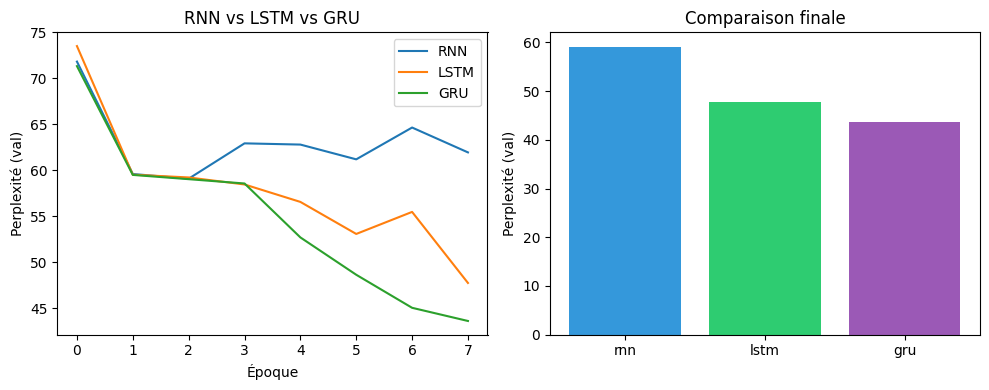

In [11]:
#Entraîne les 3 types de cellules, compare leurs courbes et perplexités finales, garde le meilleur modèle global.
cell_results = {}
histories = {}
best_model = None
best_ppl = float("inf")

for cell in ["rnn", "lstm", "gru"]:
    print(f"\n--- Seq2Seq avec {cell.upper()} ---")
    model = Seq2Seq(len(src_vocab), len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, cell)
    model, ppl, hist = train_seq2seq(model, train_loader, val_loader, clip=1.0, label=cell.upper())
    cell_results[cell] = ppl
    histories[cell] = hist
    if ppl < best_ppl:
        best_ppl = ppl
        best_model = model

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for cell, hist in histories.items():
    plt.plot(hist["val_ppl"], label=cell.upper())
plt.xlabel("Époque")
plt.ylabel("Perplexité (val)")
plt.legend()
plt.title("RNN vs LSTM vs GRU")

plt.subplot(1, 2, 2)
plt.bar(list(cell_results.keys()), list(cell_results.values()), color=["#3498db", "#2ecc71", "#9b59b6"])
plt.ylabel("Perplexité (val)")
plt.title("Comparaison finale")
plt.tight_layout()
plt.savefig(FIG_DIR / "rnn_comparison.png", dpi=150)
plt.show()


### Gradient clipping



--- Expérience gradient clipping ---


    [sans clipping] Epoch 1: loss=5.3318, val_ppl=69.23


    [sans clipping] Epoch 2: loss=3.8787, val_ppl=62.94


    [sans clipping] Epoch 4: loss=3.6435, val_ppl=58.15


  Gradient sans clipping: val perplexity=57.98


...

  Gradient clip=1.0: val perplexity=61.72


    [clip=5.0] Epoch 1: loss=5.3582, val_ppl=72.47


    [clip=5.0] Epoch 2: loss=3.8984, val_ppl=63.64


    [clip=5.0] Epoch 4: loss=3.6810, val_ppl=57.42


  Gradient clip=5.0: val perplexity=57.28


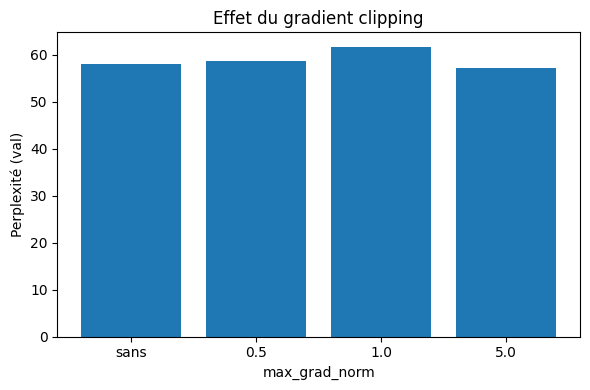

In [12]:
#Lance l'expérience et trace l'histogramme des perplexités par seuil.
print("\n--- Expérience gradient clipping ---")
clip_results = gradient_clipping_experiment(train_loader, val_loader, src_vocab, tgt_vocab)

plt.figure(figsize=(6, 4))
clip_labels = ["sans" if k == "none" else k for k in clip_results.keys()]
plt.bar(clip_labels, list(clip_results.values()))
plt.xlabel("max_grad_norm")
plt.ylabel("Perplexité (val)")
plt.title("Effet du gradient clipping")
plt.tight_layout()
plt.savefig(FIG_DIR / "gradient_clipping.png", dpi=150)
plt.show()


### Décodage greedy vs beam search


In [13]:
#Traduit 30 phrases de validation avec les deux méthodes de décodage, calcule le BLEU pour chacune, affiche 5 exemples, exporte tout en JSON.
print("\n--- Décodage greedy vs beam search ---")
sample_pairs = val_pairs[:30]
greedy_hyps, beam_hyps, refs = [], [], []

for src_text, tgt_text in sample_pairs:
    src_ids = [src_vocab.word2idx["<sos>"]] + src_vocab.encode(src_text) + [src_vocab.word2idx["<eos>"]]
    src_tensor = torch.tensor(src_ids)
    greedy_hyps.append(greedy_decode(best_model, src_tensor, tgt_vocab))
    beam_hyps.append(beam_search_decode(best_model, src_tensor, tgt_vocab))
    refs.append(tgt_text)

bleu_greedy = compute_bleu(refs, greedy_hyps)
bleu_beam = compute_bleu(refs, beam_hyps)
print(f"BLEU (greedy): {bleu_greedy:.4f}")
print(f"BLEU (beam search, width={BEAM_WIDTH}): {bleu_beam:.4f}")

print("\nExemples de traductions :")
for i in range(min(5, len(sample_pairs))):
    print(f"  FR: {sample_pairs[i][0]}")
    print(f"  Réf: {refs[i]}")
    print(f"  Greedy: {greedy_hyps[i]}")
    print(f"  Beam:   {beam_hyps[i]}")
    print()

summary = {
    "device": str(DEVICE),
    "cell_comparison_ppl": cell_results,
    "gradient_clipping": clip_results,
    "bleu_greedy": bleu_greedy,
    "bleu_beam": bleu_beam,
    "examples": [
        {"src": sample_pairs[i][0], "ref": refs[i],
         "greedy": greedy_hyps[i], "beam": beam_hyps[i]}
        for i in range(min(5, len(sample_pairs)))
    ],
}
with open(ROOT / "partie3_rnn" / "results.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Résultats exportés. Figures dans {FIG_DIR}")



--- Décodage greedy vs beam search ---
BLEU (greedy): 0.0000
BLEU (beam search, width=3): 0.0000

Exemples de traductions :
  FR: nous sommes seuls
  Réf: we're alone
  Greedy: we we
  Beam:   we we

  FR: nous sommes seules
  Réf: we're alone
  Greedy: we we
  Beam:   we we

  FR: nous sommes en colère
  Réf: we're angry
  Greedy: we we
  Beam:   we we

  FR: nous sommes armés
  Réf: we're armed
  Greedy: we we
  Beam:   we we

  FR: nous sommes armées
  Réf: we're armed
  Greedy: we we
  Beam:   we we

Résultats exportés. Figures dans c:\Users\Legion\deep-learning-projet\figures\partie3
